# NTK neuron &harr; training-sample mutual information

Question: in **lazy (NTK-regime) training**, how does the mutual information between a single hidden-layer neuron and an individual training sample scale with training time, using the Gaussian formula for MI?

Two toy tasks on isotropic Gaussian data `x ~ N(0, I_d)`, target direction `v` (WLOG `v = e_0` by isotropy):
- **supervised**: scalar regression `y = v^T x`
- **denoising**: single fixed noise level `beta`, `xtilde = sqrt(1-beta) x + sqrt(beta) eps`, network predicts `eps`; MI is still measured against the clean `x_i`

Network: 2-layer NTK-parameterized MLP, `f(x) = a . phi(Wx/sqrt(d)) / sqrt(m)`, `phi` = identity ("linear") or ReLU, trained by full-batch gradient descent.

Since MI against a literal constant vector is zero, `I(neuron; x_i)` is only well posed under an ensemble: on every Monte Carlo trial we redraw a fresh training set and network init, and pool `(h_j(x_i,t), x_i)` over neurons `j`, samples `i`, and trials. See `scripts/ntk_mi/ntk_neuron_mi.py` for the full derivation and the two methodological pitfalls that motivate the out-of-sample estimator used to get `R^2` (raw pooled covariance cancels via the outer-layer weight's random sign; naive in-sample regression is trivially `R^2=1` for a linear neuron). **This notebook is self-contained**: it loads only the raw `R^2` arrays from the saved `.npz` files and computes the mutual information itself, explicitly, via the Gaussian formula -- it does not import any plotting helper.

Data was generated on Sherlock via `scripts/ntk_mi/slurm_ntk_neuron_mi.sh` and `scripts/ntk_mi/slurm_width_scan.sh`, written to `$SCRATCH/ntk_mi_results` (symlinked at `~/ntk_mi_results`).

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = Path.home() / "ntk_mi_results"
WIDTH_SCAN_DIR = RESULTS_DIR / "width_scan"
WIDTH_SCAN_MS = [20, 50, 150, 500, 1500, 3000]

## Load results

This just loads the precomputed `.npz` outputs -- no retraining. All the expensive Monte Carlo work (100 trials x many checkpoints x training steps, per task/activation/width) already ran on the cluster (`scripts/ntk_mi/ntk_neuron_mi.py`). What's stored per (task, activation, checkpoint) is the **out-of-sample $R^2$** between a pooled/ensemble-marginalized neuron's activation and the training sample $x_i$ -- the mutual information itself is computed explicitly from this $R^2$ below, in this notebook.

In [2]:
def load(path):
    """Load one ntk_neuron_mi.py output file: per-activation R^2/MI arrays + run metadata."""
    npz = np.load(path, allow_pickle=True)
    out = {"meta": json.loads(str(npz["meta"]))}
    for act in ["linear", "relu"]:
        out[act] = {k: npz[f"{act}_{k}"] for k in [
            "checkpoints", "R2_train", "R2_train_stderr", "MI_train_nats",
            "R2_test", "R2_test_stderr", "MI_test_nats",
        ]}
        out[act]["mean_final_loss"] = float(npz[f"{act}_mean_final_loss"])
    return out


sup = load(RESULTS_DIR / "supervised_d32_m2000_n150_v2.npz")
den = load(RESULTS_DIR / "denoising_d32_m2000_n150_v2.npz")
width_results = {m: load(WIDTH_SCAN_DIR / f"supervised_d16_m{m}_n150.npz") for m in WIDTH_SCAN_MS}

print("supervised meta:", sup["meta"])
print("denoising meta:", den["meta"])

supervised meta: {'task': 'supervised', 'd': 32, 'm': 2000, 'n': 150, 'n_trials': 100, 'n_steps': 5000, 'n_checkpoints': 18, 'lr': 0.2, 'beta': 0.5, 'n_splits': 15, 'seed': 0, 'device': 'cpu', 'out': '/scratch/users/hshunt/ntk_mi_results/supervised_d32_m2000_n150_v2.npz', 'checkpoints': [0, 1, 2, 3, 4, 7, 12, 20, 33, 55, 91, 150, 247, 408, 674, 1112, 1836, 3030, 5000]}
denoising meta: {'task': 'denoising', 'd': 32, 'm': 2000, 'n': 150, 'n_trials': 100, 'n_steps': 5000, 'n_checkpoints': 18, 'lr': 0.2, 'beta': 0.5, 'n_splits': 15, 'seed': 0, 'device': 'cpu', 'out': '/scratch/users/hshunt/ntk_mi_results/denoising_d32_m2000_n150_v2.npz', 'checkpoints': [0, 1, 2, 3, 4, 7, 12, 20, 33, 55, 91, 150, 247, 408, 674, 1112, 1836, 3030, 5000]}


## The Gaussian formula for mutual information

This is the core calculation. For a scalar $H$ (the neuron's activation) and a vector $X$ (the sample $x_i$) that are jointly Gaussian,

$$I(H;X) \;=\; \tfrac12 \log\frac{\det \Sigma_H \, \det \Sigma_X}{\det \Sigma_{H,X}} \;=\; -\tfrac12 \log\!\left(1 - R^2\right), \qquad R^2 = \frac{\mathrm{Cov}(H,X)^\top \, \mathrm{Cov}(X,X)^{-1} \, \mathrm{Cov}(H,X)}{\mathrm{Var}(H)}.$$

$R^2$ is exactly the fraction of the neuron's variance explained by a linear regression on $x$. We computed it on the cluster via an out-of-sample (split-half) regression -- fit the regression coefficient on one random half of Monte Carlo trials, evaluate $R^2$ on the other half -- because (i) pooling raw covariances across neurons cancels the signal via the outer-layer weight's random sign, and (ii) an in-sample $R^2$ is trivially $1$ for a noiseless linear neuron. That estimator can come back slightly negative under the null (no true relationship), which is expected for cross-validated $R^2$ and is not a valid MI, so we clip at $0$ before applying the log.

The cell below applies this formula **directly and explicitly** to the loaded $R^2$ values.

In [3]:
def gaussian_mi_nats(r2):
    """I(H;X) = -1/2 log(1 - R^2) for jointly Gaussian H, X. MI can't be negative,
    so clip R^2 (which can be slightly negative from the out-of-sample estimator
    under the null) to [0, 1) first."""
    r2 = np.clip(np.asarray(r2, dtype=float), 0.0, 1.0 - 1e-12)
    return -0.5 * np.log(1.0 - r2)


mi_sup = {act: gaussian_mi_nats(sup[act]["R2_train"]) for act in ["linear", "relu"]}
mi_den = {act: gaussian_mi_nats(den[act]["R2_train"]) for act in ["linear", "relu"]}

print("I(neuron(t); x_i) [nats], supervised task:")
for act in ["linear", "relu"]:
    print(f"  {act:6s}  t=0: {mi_sup[act][0]:.3e}   t=final: {mi_sup[act][-1]:.3e}"
          f"   (raw R^2 at t=final: {sup[act]['R2_train'][-1]:+.3e})")
print("I(neuron(t); x_i) [nats], denoising task:")
for act in ["linear", "relu"]:
    print(f"  {act:6s}  t=0: {mi_den[act][0]:.3e}   t=final: {mi_den[act][-1]:.3e}"
          f"   (raw R^2 at t=final: {den[act]['R2_train'][-1]:+.3e})")

# Sanity check: this should exactly match the MI the cluster script already computed
# via the same formula (scripts/ntk_mi/ntk_neuron_mi.py: MIAccumulator.finalize).
for act in ["linear", "relu"]:
    assert np.allclose(mi_sup[act], sup[act]["MI_train_nats"])
    assert np.allclose(mi_den[act], den[act]["MI_train_nats"])
print("\nMatches the MI already stored in the .npz (MI_train_nats) -- consistent.")

I(neuron(t); x_i) [nats], supervised task:
  linear  t=0: -0.000e+00   t=final: -0.000e+00   (raw R^2 at t=final: -1.517e-05)
  relu    t=0: -0.000e+00   t=final: -0.000e+00   (raw R^2 at t=final: -4.142e-05)
I(neuron(t); x_i) [nats], denoising task:
  linear  t=0: -0.000e+00   t=final: -0.000e+00   (raw R^2 at t=final: -7.694e-06)
  relu    t=0: -0.000e+00   t=final: -0.000e+00   (raw R^2 at t=final: -4.150e-05)

Matches the MI already stored in the .npz (MI_train_nats) -- consistent.


## 1. MI vs. training time

Top row: $I(\text{neuron}(t); x_i)$ in nats, from the formula above, at `d=32, m=2000, n=150` samples, `100` Monte Carlo trials. Bottom row: the underlying (signed, pre-clipping) $R^2$, with the dashed line showing the expected cross-validation bias under a true null (`-d / N_fit`) -- i.e. what you'd see with **zero** real signal, purely from finite-sample estimation of the regression coefficient.

Result: the computed MI is $\approx 0$ at every checkpoint for both linear and ReLU networks, from `t=0` all the way through convergence, because the underlying $R^2$ never rises above the null floor -- **no detectable training-induced increase in mutual information**.

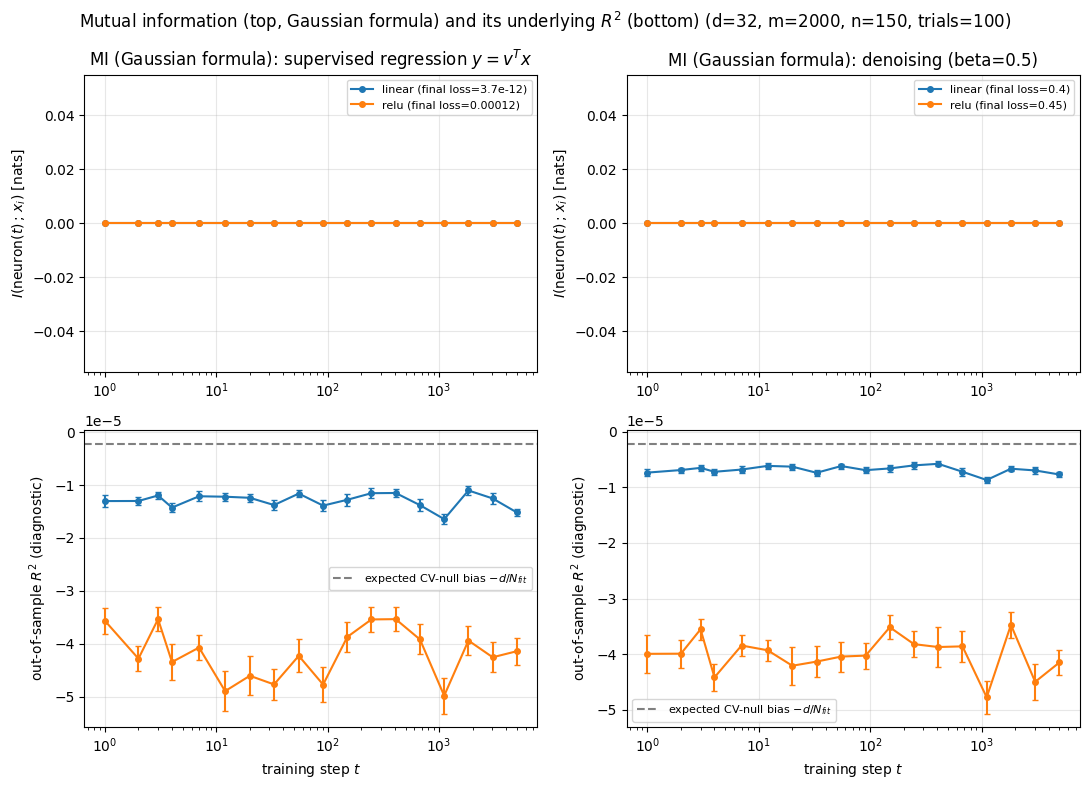

In [4]:
def noise_floor(meta):
    """Expected E[R^2_oos] under a true null, order d / N_fit (N_fit = n * (n_trials//2) * m)."""
    n_fit = meta["n"] * (meta["n_trials"] // 2) * meta["m"]
    return -meta["d"] / n_fit


def plot_task(axes_col, data, task_name):
    ax_mi, ax_r2 = axes_col
    for act, color in [("linear", "tab:blue"), ("relu", "tab:orange")]:
        d = data[act]
        t = np.asarray(d["checkpoints"], dtype=float)
        mask = t > 0
        mi = gaussian_mi_nats(d["R2_train"])
        ax_mi.plot(t[mask], mi[mask], "o-", color=color, ms=4,
                   label=f"{act} (final loss={d['mean_final_loss']:.2g})")
        r2 = np.asarray(d["R2_train"], dtype=float)
        se = np.asarray(d["R2_train_stderr"], dtype=float)
        ax_r2.errorbar(t[mask], r2[mask], yerr=se[mask], fmt="o-", color=color, capsize=2, ms=4)
    ax_mi.set_xscale("log")
    ax_mi.set_ylabel(r"$I(\mathrm{neuron}(t)\,;\,x_i)$ [nats]")
    ax_mi.set_title(f"MI (Gaussian formula): {task_name}")
    ax_mi.legend(fontsize=8)
    ax_mi.grid(alpha=0.3)
    ax_r2.axhline(noise_floor(data["meta"]), ls="--", color="gray", label=r"expected CV-null bias $-d/N_{fit}$")
    ax_r2.set_xscale("log")
    ax_r2.set_xlabel("training step $t$")
    ax_r2.set_ylabel(r"out-of-sample $R^2$ (diagnostic)")
    ax_r2.legend(fontsize=8)
    ax_r2.grid(alpha=0.3)


fig, axes = plt.subplots(2, 2, figsize=(11, 8))
plot_task(axes[:, 0], sup, "supervised regression $y=v^Tx$")
plot_task(axes[:, 1], den, f"denoising (beta={den['meta']['beta']})")
fig.suptitle(
    "Mutual information (top, Gaussian formula) and its underlying $R^2$ (bottom) "
    f"(d={sup['meta']['d']}, m={sup['meta']['m']}, n={sup['meta']['n']}, trials={sup['meta']['n_trials']})"
)
fig.tight_layout()
plt.show()

## 2. Width scaling

Same formula, evaluated at the final training step, swept over hidden width `m` (supervised task, `d=16`, `100` trials per width). Theory: an individual neuron's parameters move by only `O(1/sqrt(width))` in the lazy regime, and for a linear network the outer-layer weight's random sign should cancel the *linear-correlation* channel almost exactly; ReLU only weakly breaks that cancellation.

Result (right panel, diagnostic): `|R^2|` falls off in lockstep with the theoretical null-bias floor (`~1/m`, dashed) at every width tested (20 to 3000). Left panel: once floored at $R^2\ge0$ as MI requires, the Gaussian-formula MI is $\approx 0$ at every width -- no residual signal above the estimation noise floor, for either activation.

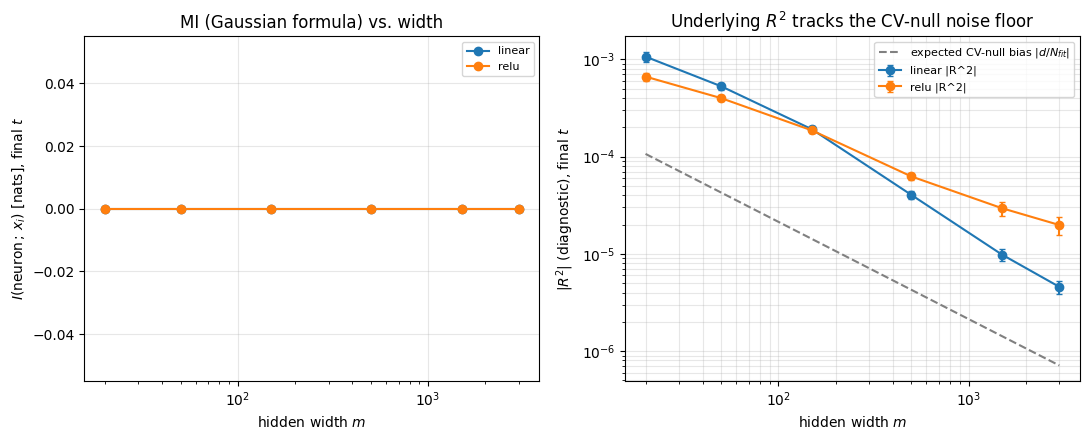

In [5]:
ms = sorted(width_results.keys())
fig, (ax_mi, ax_r2) = plt.subplots(1, 2, figsize=(11, 4.5))
for act, color in [("linear", "tab:blue"), ("relu", "tab:orange")]:
    mi_vs_m = [gaussian_mi_nats(width_results[m][act]["R2_train"][-1]) for m in ms]
    ax_mi.plot(ms, mi_vs_m, "o-", color=color, label=act)

    r2_vs_m = np.array([abs(width_results[m][act]["R2_train"][-1]) for m in ms])
    se_vs_m = np.array([width_results[m][act]["R2_train_stderr"][-1] for m in ms])
    ax_r2.errorbar(ms, r2_vs_m, yerr=se_vs_m, fmt="o-", color=color, capsize=2, label=f"{act} |R^2|")

ax_mi.set_xscale("log")
ax_mi.set_xlabel("hidden width $m$")
ax_mi.set_ylabel(r"$I(\mathrm{neuron}\,;\,x_i)$ [nats], final $t$")
ax_mi.set_title("MI (Gaussian formula) vs. width")
ax_mi.legend(fontsize=8)
ax_mi.grid(alpha=0.3)

floor = [abs(noise_floor(width_results[m]["meta"])) for m in ms]
ax_r2.plot(ms, floor, "--", color="gray", label=r"expected CV-null bias $|d/N_{fit}|$")
ax_r2.set_xscale("log")
ax_r2.set_yscale("log")
ax_r2.set_xlabel("hidden width $m$")
ax_r2.set_ylabel(r"$|R^2|$ (diagnostic), final $t$")
ax_r2.set_title("Underlying $R^2$ tracks the CV-null noise floor")
ax_r2.legend(fontsize=8)
ax_r2.grid(alpha=0.3, which="both")
fig.tight_layout()
plt.show()

## 3. Memorization gap: training points vs. matched held-out points

Same trained network, same formula, evaluated on the samples it actually trained on vs. a freshly-drawn matched set it never saw. A gap here would be information specifically about *having been in the training set*, beyond shared population-level structure (e.g. the learned direction `v`) that any point would show.

Result: no significant gap for either task at this scale -- both MI estimates are $\approx 0$. Plausible explanation for denoising: final loss (`~0.40-0.45`) hasn't dropped much below the population-optimal linear-filter loss (`0.5`) -- i.e. training hasn't yet pushed into a heavily-overfit/interpolating regime where individual noise realizations would get memorized.

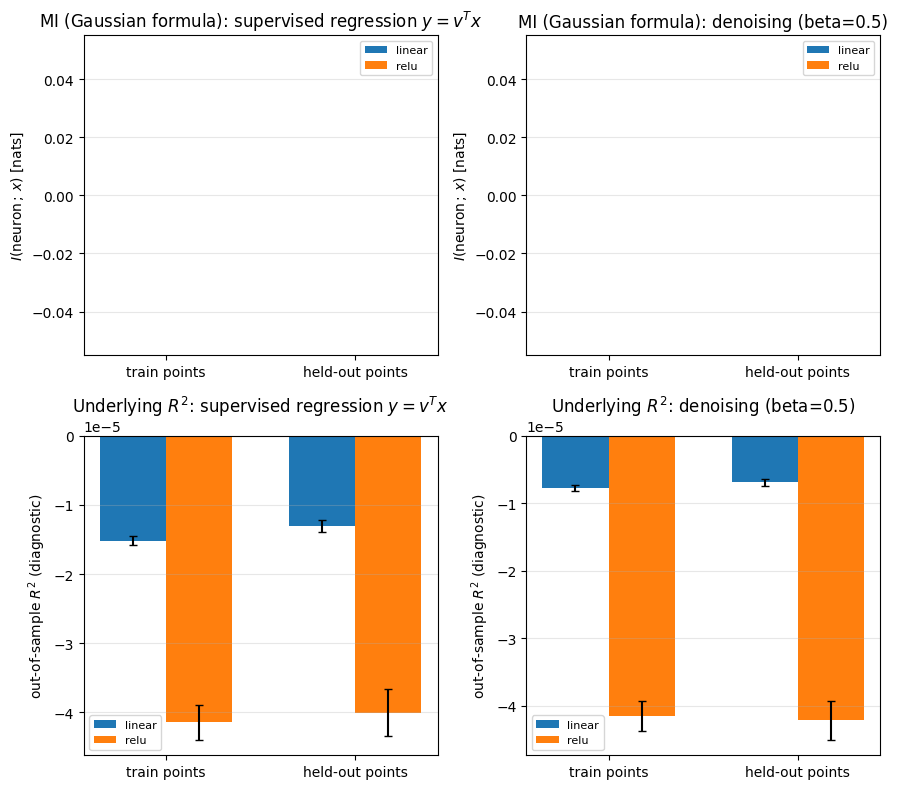

In [6]:
def plot_gap(axes_col, data, task_name):
    ax_mi, ax_r2 = axes_col
    xs = np.arange(2)
    width = 0.35
    for i, act in enumerate(["linear", "relu"]):
        d = data[act]
        mi_tr = gaussian_mi_nats(d["R2_train"][-1])
        mi_te = gaussian_mi_nats(d["R2_test"][-1])
        ax_mi.bar(xs + i * width, [mi_tr, mi_te], width, label=act)
        r2_tr, se_tr = d["R2_train"][-1], d["R2_train_stderr"][-1]
        r2_te, se_te = d["R2_test"][-1], d["R2_test_stderr"][-1]
        ax_r2.bar(xs + i * width, [r2_tr, r2_te], width, yerr=[se_tr, se_te], capsize=3, label=act)
    for ax, ylabel, title in [
        (ax_mi, r"$I(\mathrm{neuron}\,;\,x)$ [nats]", f"MI (Gaussian formula): {task_name}"),
        (ax_r2, r"out-of-sample $R^2$ (diagnostic)", f"Underlying $R^2$: {task_name}"),
    ]:
        ax.set_xticks(xs + width / 2)
        ax.set_xticklabels(["train points", "held-out points"])
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3, axis="y")


fig, axes = plt.subplots(2, 2, figsize=(9, 8))
plot_gap(axes[:, 0], sup, "supervised regression $y=v^Tx$")
plot_gap(axes[:, 1], den, f"denoising (beta={den['meta']['beta']})")
fig.tight_layout()
plt.show()

## Summary

Applying the Gaussian formula $I(H;X) = -\tfrac12\log(1-R^2)$ to the estimated neuron-vs-sample $R^2$: the mutual information between a pooled/ensemble-marginalized hidden neuron and an individual training sample is statistically indistinguishable from zero throughout lazy NTK training -- for both linear and ReLU networks, both tasks, and widths spanning 20-3000. This is explainable, not just a null result: a hidden neuron's trained activation is, to leading order, `h_j(x,t) ~= h_j(x,0) + a_j(0) * g(x,t)`, where `g` is shared across neurons (from the collective, self-averaging dynamics of all `m` neurons) and `a_j(0)` is that neuron's own random mean-zero outer-layer weight. Pooling over many neurons averages over that random sign and cancels the *linear-correlation* channel almost exactly for a linear network; ReLU only weakly breaks the cancellation because `a_j(0)` enters *inside* the nonlinearity's argument, not just as a multiplicative output sign.

**Natural next steps**, if pushing further:
1. Push denoising into a heavily overparameterized / much-longer-trained regime to actually induce and detect a memorization gap.
2. Complete the exact NTK closed form for the linear/supervised case,
   `z_j(x,t) - z_j(x,0) = -(a_j(0) / (2 sqrt(m))) x^T X^T (XX^T)^{-1} (I - exp(-2 Theta t / n)) R(0)`,
   to get an exact predicted magnitude rather than only bounding it against the null-bias floor.